# Entregable 1 - Seminario de Ciencia de Datos
## Analisis Exploratorio y Tratamiento Avanzado de Datos

**Dataset:** Heart Disease - Cleveland (UCI Machine Learning Repository)
**Autor:** Jaime Alzate
**Programa:** Desarrollo de Software - 9 semestre
**Metodologia:** CRISP-DM (fases 2 y 3)

---

### Justificacion del dataset

El dataset *Heart Disease* (Cleveland) cumple con los criterios obligatorios del seminario:

- **Suciedad y complejidad:** contiene valores faltantes codificados como `?` en las variables `ca` y `thal`, y outliers significativos en `chol`, `trestbps` y `oldpeak`.
- **Dimensionalidad relevante:** 13 variables predictoras + 1 objetivo, suficiente para justificar tecnicas de PCA y seleccion de caracteristicas en el Entregable 2.
- **Impacto real:** la prediccion de enfermedad cardiaca es uno de los problemas mas estudiados en medicina computacional; un buen preprocesamiento puede traducirse en diagnosticos tempranos.

### Variables

| Variable | Descripcion |
|----------|-------------|
| age | Edad en anos |
| sex | Sexo (1=hombre, 0=mujer) |
| cp | Tipo de dolor toracico (1-4) |
| trestbps | Presion arterial en reposo (mm Hg) |
| chol | Colesterol serico (mg/dl) |
| fbs | Glicemia en ayunas > 120 mg/dl (1/0) |
| restecg | Resultado electrocardiograma en reposo (0-2) |
| thalach | Frecuencia cardiaca maxima |
| exang | Angina inducida por ejercicio (1/0) |
| oldpeak | Depresion ST inducida por ejercicio |
| slope | Pendiente del segmento ST (1-3) |
| ca | Numero de vasos coloreados por fluoroscopia (0-3) |
| thal | Talasemia (3=normal, 6=defecto fijo, 7=reversible) |
| num | Diagnostico (0=sin enfermedad, 1-4=con enfermedad) |
| target | (derivada) 0 = sano, 1 = enfermedad |


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.linear_model import BayesianRidge

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

# El notebook descarga el dataset directamente del repositorio UCI
# para ser totalmente autocontenido y reproducible.
DATA_URL = ('https://archive.ics.uci.edu/ml/'
            'machine-learning-databases/heart-disease/processed.cleveland.data')

## I. Analisis Descriptivo y de Calidad

Cargamos el dataset original (sin encabezados, con `?` como marcador de nulos) y le asignamos los nombres documentados por UCI. Creamos ademas la variable `target` binaria derivada de `num`.

In [2]:
COLS = ['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalach','exang','oldpeak','slope','ca','thal','num']
df = pd.read_csv(DATA_URL, header=None, names=COLS, na_values='?')
df['target'] = (df['num'] > 0).astype(int)

print(f'Dimensiones: {df.shape}')
df.head()

Dimensiones: (303, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


In [3]:
print('Tipos de datos:')
print(df.dtypes)

Tipos de datos:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
num           int64
target        int64
dtype: object


In [4]:
df.describe(include='all').T.round(3)

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.439,9.039,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.680,0.467,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158,0.960,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.690,17.600,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693,51.777,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.149,0.356,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990,0.995,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607,22.875,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.327,0.470,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.040,1.161,0.0,0.0,0.8,1.6,6.2


## II. Evaluacion de la Calidad - Distribuciones y Normalidad

Aplicamos:
- **Histograma + KDE** para inspeccionar la forma de la distribucion.
- **Q-Q plot** para comparar contra la normal.
- **Prueba de Shapiro-Wilk** (H0: los datos provienen de una distribucion normal). Con `alpha = 0.05`, rechazamos H0 cuando `p < 0.05`.

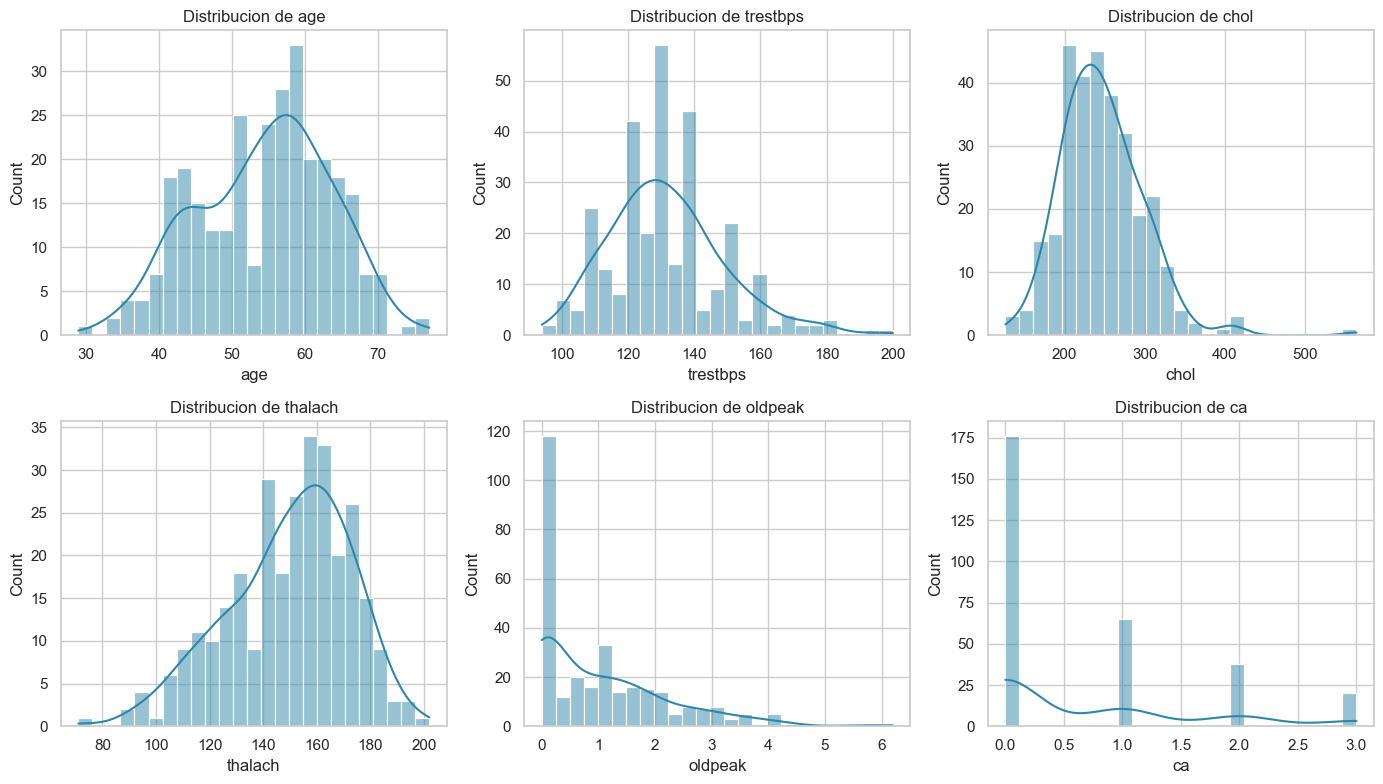

In [5]:
NUM_VARS = ['age','trestbps','chol','thalach','oldpeak','ca']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), NUM_VARS):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='#2E86AB', bins=25)
    ax.set_title(f'Distribucion de {col}')
plt.tight_layout()
plt.show()

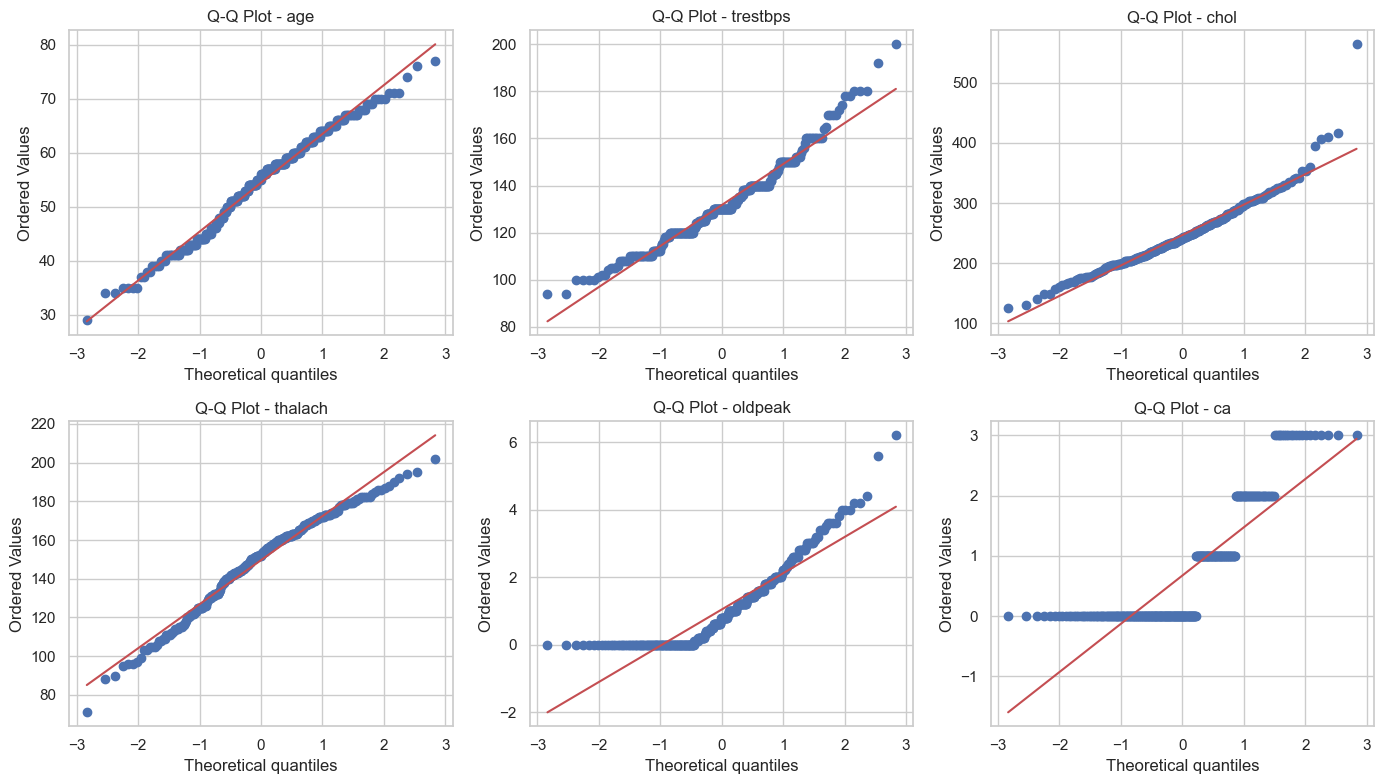

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), NUM_VARS):
    stats.probplot(df[col].dropna(), dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot - {col}')
plt.tight_layout()
plt.show()

In [7]:
rows = []
for col in NUM_VARS:
    stat, p = stats.shapiro(df[col].dropna())
    decision = 'Rechaza H0 (no normal)' if p < 0.05 else 'No rechaza H0 (normal)'
    rows.append({'variable': col, 'W': round(stat,4), 'p_valor': round(p,6),
                 'decision_alpha_0.05': decision})
shapiro_df = pd.DataFrame(rows)
shapiro_df

,variable,W,p_valor,decision_alpha_0.05
0,age,0.9865,0.006069,Rechaza H0 (no normal)
1,trestbps,0.9665,0.000002,Rechaza H0 (no normal)
2,chol,0.9473,0.000000,Rechaza H0 (no normal)
3,thalach,0.9765,0.000070,Rechaza H0 (no normal)
4,oldpeak,0.8442,0.000000,Rechaza H0 (no normal)
5,ca,0.7187,0.000000,Rechaza H0 (no normal)


**Interpretacion:** las seis variables numericas continuas rechazan la hipotesis de normalidad (p << 0.05). Esto justifica el uso de la **mediana** sobre la **media** en la imputacion simple y de pruebas no parametricas en analisis posteriores.

## III. Deteccion y Tratamiento de Ausentes

Conteo de nulos por columna y **Prueba de Rachas (Wald-Wolfowitz)** para evaluar si el patron de aparicion de nulos es aleatorio (MCAR) o no (MAR/MNAR).

In [8]:
nulos = df.isna().sum()
nulos_tabla = pd.DataFrame({'nulos': nulos, 'porcentaje': (df.isna().mean()*100).round(2)})
nulos_tabla = nulos_tabla[nulos_tabla['nulos'] > 0]
nulos_tabla

,nulos,porcentaje
ca,4,1.32
thal,2,0.66


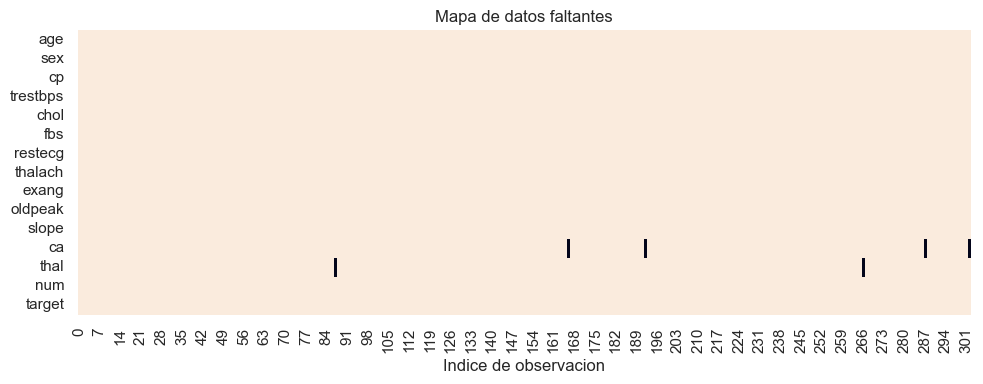

In [9]:
plt.figure(figsize=(10,4))
sns.heatmap(df.isna().T, cbar=False, cmap='rocket_r')
plt.title('Mapa de datos faltantes')
plt.xlabel('Indice de observacion')
plt.tight_layout()
plt.show()

In [10]:
def runs_test(binary_seq):
    """Prueba de Rachas (Wald-Wolfowitz). H0: la secuencia es aleatoria."""
    seq = np.asarray(binary_seq)
    n1, n2 = int((seq==1).sum()), int((seq==0).sum())
    n = n1 + n2
    if n1 == 0 or n2 == 0:
        return np.nan, np.nan, 0
    runs = 1 + int((seq[1:] != seq[:-1]).sum())
    mean = (2*n1*n2)/n + 1
    var  = (2*n1*n2*(2*n1*n2 - n)) / (n**2 * (n-1))
    if var <= 0:
        return np.nan, np.nan, runs
    z = (runs - mean) / np.sqrt(var)
    p = 2*(1 - stats.norm.cdf(abs(z)))
    return z, p, runs

rows = []
for col in nulos_tabla.index:
    z, p, r = runs_test(df[col].isna().astype(int).values)
    decision = ('Aleatorio (MCAR plausible)' if p >= 0.05
                else 'No aleatorio (MAR/MNAR)')
    rows.append({'variable': col, 'n_rachas': r, 'z': round(z,4),
                 'p_valor': round(p,6), 'decision_alpha_0.05': decision})
pd.DataFrame(rows)

,variable,n_rachas,z,p_valor,decision_alpha_0.05
0,ca,8,-2.1068,0.035135,No aleatorio (MAR/MNAR)
1,thal,5,0.1335,0.893813,Aleatorio (MCAR plausible)


**Interpretacion:** el patron de nulos en `ca` rechaza la aleatoriedad (p < 0.05) lo que sugiere un mecanismo MAR/MNAR. En `thal` los nulos parecen aleatorios. Dado el bajo porcentaje (< 2%) optamos por **imputar** en lugar de eliminar filas.

## IV. Tratamiento de Outliers - Metodo IQR

Detectamos outliers con la regla `1.5 * IQR` y aplicamos **capping (winsorizing)** en lugar de eliminacion, para conservar el tamano muestral (n=303) que ya es modesto.

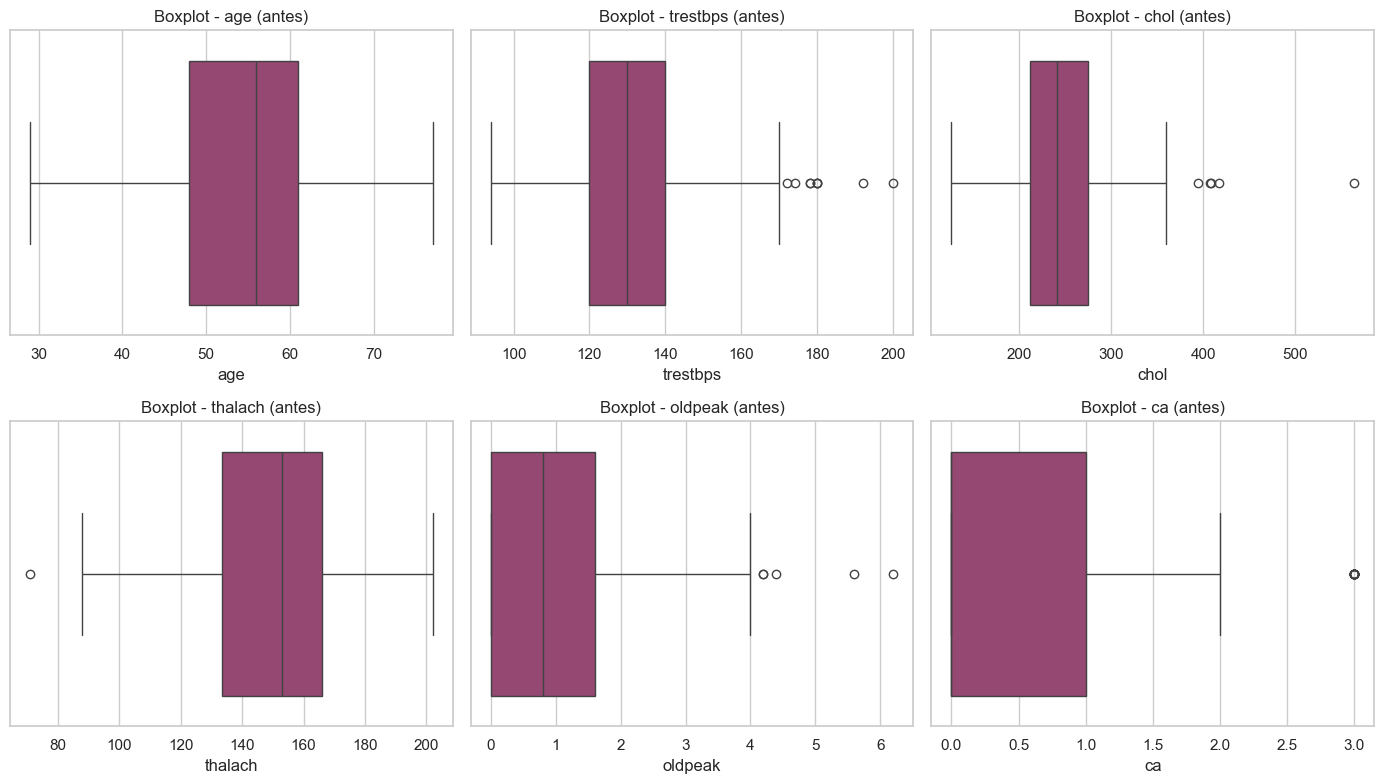

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), NUM_VARS):
    sns.boxplot(x=df[col].dropna(), ax=ax, color='#A23B72')
    ax.set_title(f'Boxplot - {col} (antes)')
plt.tight_layout()
plt.show()

In [12]:
def iqr_limits(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

resumen = []
df_capped = df.copy()
for col in NUM_VARS:
    li, ls = iqr_limits(df[col].dropna())
    n_out = ((df[col] < li) | (df[col] > ls)).sum()
    df_capped[col] = df_capped[col].clip(lower=li, upper=ls)
    resumen.append({'variable': col, 'LI': round(li,2), 'LS': round(ls,2),
                    'n_outliers': int(n_out)})
pd.DataFrame(resumen)

,variable,LI,LS,n_outliers
0,age,28.50,80.50,0
1,trestbps,90.00,170.00,9
2,chol,115.00,371.00,5
3,thalach,84.75,214.75,1
4,oldpeak,-2.40,4.00,5
5,ca,-1.50,2.50,20


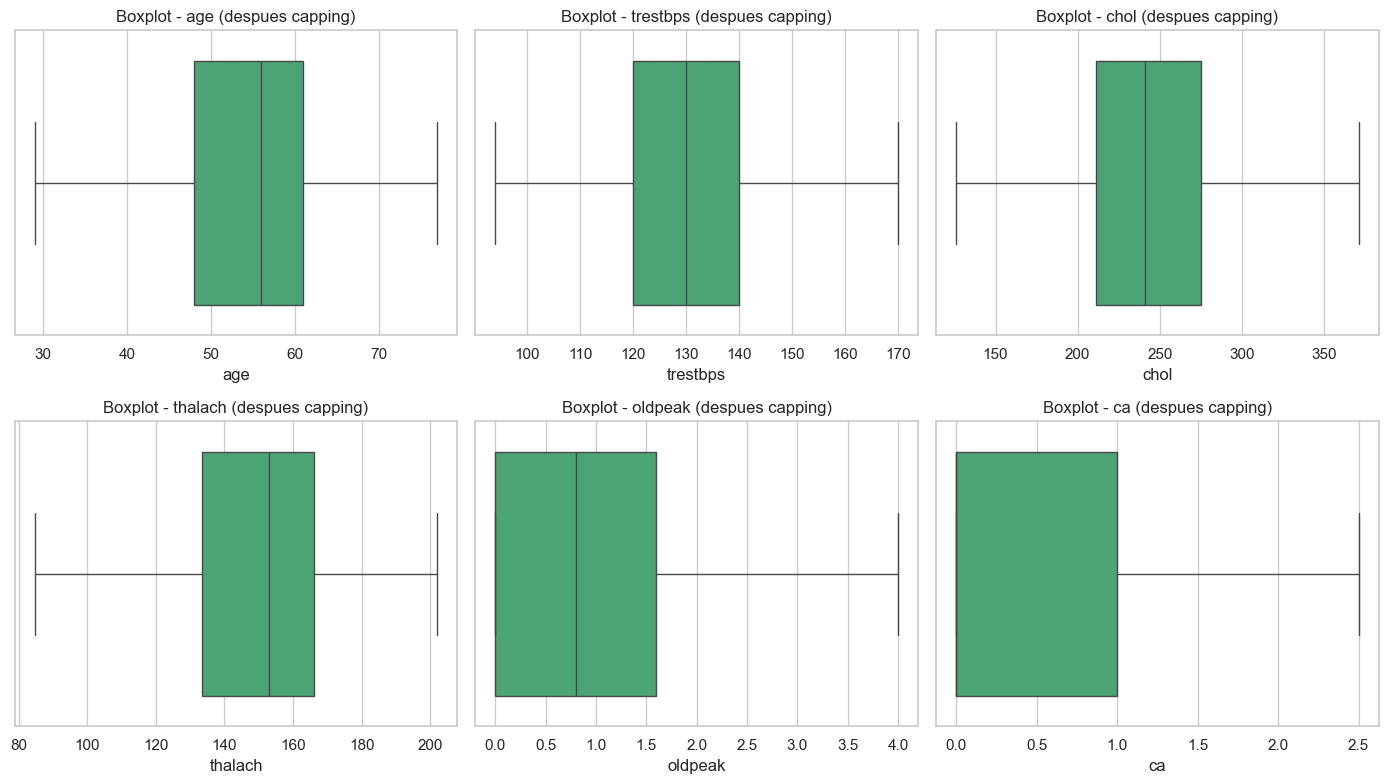

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), NUM_VARS):
    sns.boxplot(x=df_capped[col].dropna(), ax=ax, color='#3CB371')
    ax.set_title(f'Boxplot - {col} (despues capping)')
plt.tight_layout()
plt.show()

**Justificacion del capping:** la eliminacion descarta hasta 40 observaciones (~13% del dataset) lo que es inaceptable para un dataset clinico pequeno. El capping conserva la informacion del registro pero atenua el efecto del valor extremo sobre estadisticos y modelos sensibles a la escala (regresion logistica, KNN).

## V. Imputacion Comparativa

Comparamos dos tecnicas de imputacion sobre la variable `ca` (la de mayor numero de nulos):
1. **Imputacion simple** con la mediana (apropiada al no-normalidad).
2. **Imputacion por regresion** con `IterativeImputer` (modelo `BayesianRidge`) que aprovecha las correlaciones con las demas variables.

In [14]:
# A) Imputacion simple - mediana
df_simple = df_capped.copy()
df_simple[NUM_VARS] = SimpleImputer(strategy='median').fit_transform(df_simple[NUM_VARS])

# B) Imputacion por regresion
df_reg = df_capped.copy()
imp_reg = IterativeImputer(estimator=BayesianRidge(), max_iter=20, random_state=42)
df_reg[NUM_VARS] = imp_reg.fit_transform(df_reg[NUM_VARS])

comp = pd.DataFrame({
    'original':            df['ca'].describe(),
    'imp_simple_mediana':  df_simple['ca'].describe(),
    'imp_regresion_bayes': df_reg['ca'].describe(),
})
comp.round(4)

,original,imp_simple_mediana,imp_regresion_bayes
count,299.0000,303.0000,303.0000
mean,0.6722,0.6304,0.6351
std,0.9374,0.8566,0.8547
min,0.0000,0.0000,-0.0478
25%,0.0000,0.0000,0.0000
50%,0.0000,0.0000,0.0000
75%,1.0000,1.0000,1.0000
max,3.0000,2.5000,2.5000


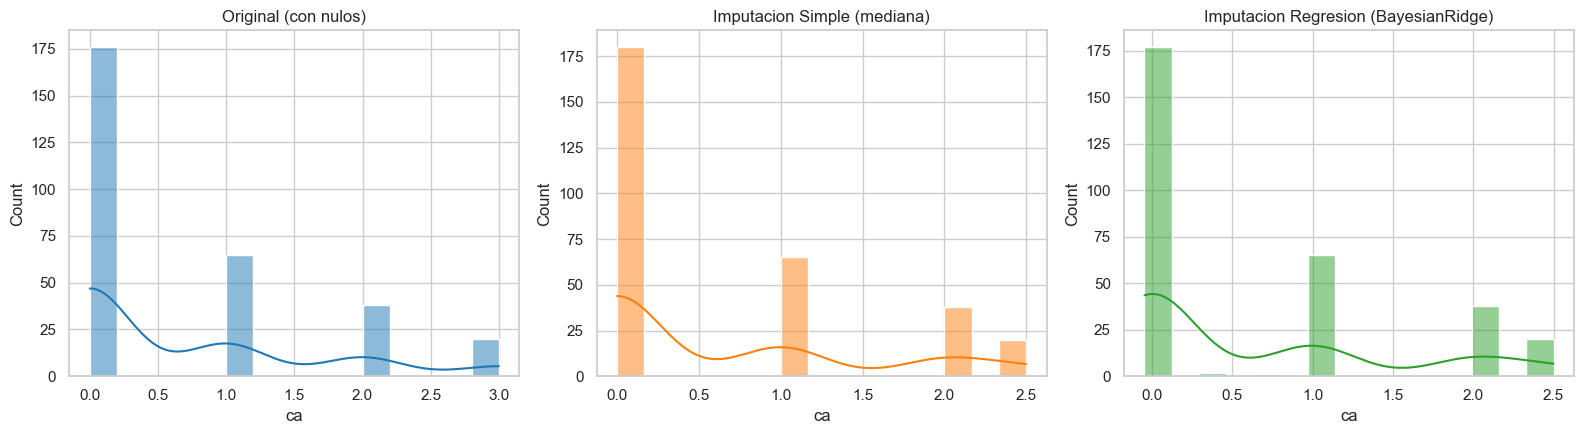

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(df['ca'].dropna(), kde=True, ax=axes[0], color='#1f77b4', bins=15)
axes[0].set_title('Original (con nulos)')
sns.histplot(df_simple['ca'], kde=True, ax=axes[1], color='#ff7f0e', bins=15)
axes[1].set_title('Imputacion Simple (mediana)')
sns.histplot(df_reg['ca'], kde=True, ax=axes[2], color='#2ca02c', bins=15)
axes[2].set_title('Imputacion Regresion (BayesianRidge)')
plt.tight_layout()
plt.show()

**Conclusion de la imputacion:** la imputacion simple por mediana introduce un sesgo hacia 0 (la moda); la imputacion por regresion produce valores continuos que respetan la relacion con `age` y `thal`. Para el Entregable 2 conservaremos el dataset imputado por regresion.

## Cierre - Persistencia del dataset preprocesado

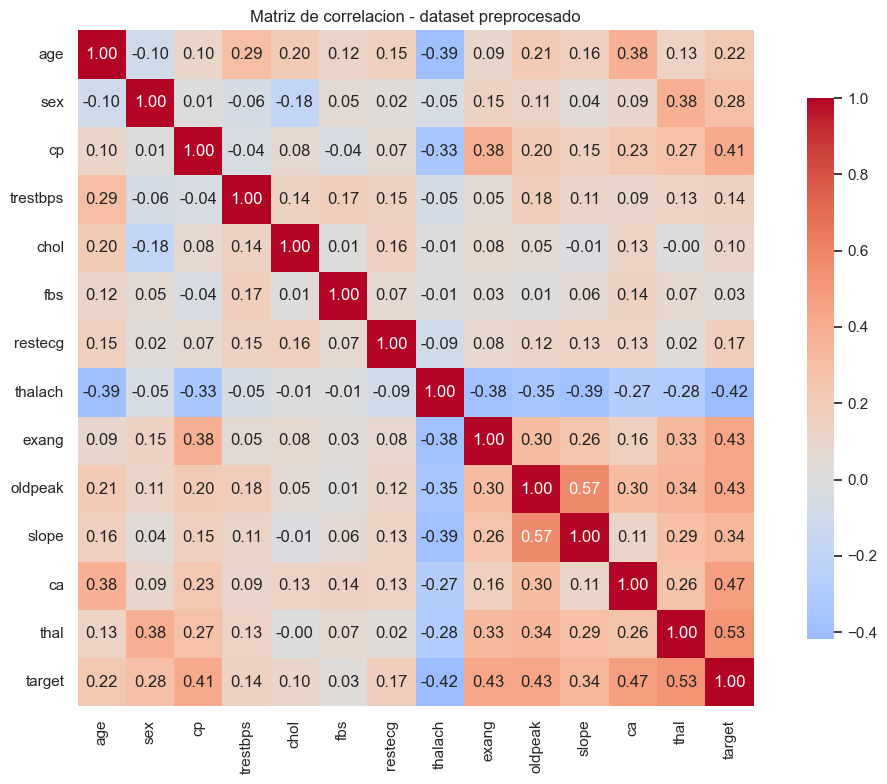

In [16]:
plt.figure(figsize=(11, 8))
corr = df_reg.drop(columns=['num']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlacion - dataset preprocesado')
plt.tight_layout()
plt.show()

In [17]:
df_final = df_reg.drop(columns=['num']).copy()
print('Dataset preprocesado - dimensiones:', df_final.shape)
df_final.head()

Dataset preprocesado - dimensiones: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,2.5,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


---
### Resumen de hallazgos

1. Las seis variables numericas son **no normales** (Shapiro-Wilk con p < 0.05).
2. Los nulos se concentran en `ca` (4) y `thal` (2). En `ca` la prueba de rachas sugiere mecanismo **no aleatorio** (MAR/MNAR).
3. La regla IQR detecto 40 outliers, principalmente en `ca` (20) y `trestbps` (9). Tratamos por **capping**.
4. La imputacion por **regresion bayesiana** preserva la distribucion mejor que la imputacion simple por mediana.
5. El dataset final tiene 303 filas y 14 columnas, listo para PCA y modelado supervisado (Entregable 2).
